In [2]:
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import ScalarFormatter  # <-- NEW

%matplotlib inline

ROOT_DIR = Path("../metrex/dataset/version_1")
VALID_EXTS = {".sv"}
EXCLUDE_DIR_PATTERNS = {".git", ".venv", "__pycache__"}

print("ROOT_DIR resolves to:", ROOT_DIR.resolve())
print("Extensions included:", VALID_EXTS)


ROOT_DIR resolves to: /Users/aarushgoradia/Documents/malik25_26/metrex/dataset/version_1
Extensions included: {'.sv'}


In [3]:
# Regex patterns for SVA-related keywords
RE_ASSERT   = re.compile(r"\bassert\b")
RE_ASSUME   = re.compile(r"\bassume\b")
RE_COVER    = re.compile(r"\bcover\b")
RE_PROPERTY = re.compile(r"\bproperty\b")


def is_verilog_file(path: Path) -> bool:
    """Return True if this is a SystemVerilog file we care about (.sv only)."""
    return path.suffix.lower() in VALID_EXTS


def walk_verilog_files(root: Path):
    """Yield all .sv files under the given root directory."""
    for dirpath, dirnames, filenames in os.walk(root):
        # prune excluded dirs in-place
        dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIR_PATTERNS]
        for fname in filenames:
            fpath = Path(dirpath) / fname
            if is_verilog_file(fpath):
                yield fpath


def scan_file(path: Path, root: Path):
    """
    Collect statistics for a single .sv file (SVA + whatever else is inside).
    Returns a dict of stats, or None if the file couldn't be read.
    """
    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"WARNING: could not read {path}: {e}")
        return None

    lines = text.splitlines()
    num_lines = len(lines)
    num_chars = len(text)

    # simple token estimate: non-space groups
    est_tokens_whitespace = len(re.findall(r"\S+", text))
    # rough LLM-ish estimate: 4 chars ≈ 1 token
    est_tokens_char4 = int(round(num_chars / 4)) if num_chars > 0 else 0

    # Count non-empty and comment lines
    num_nonempty = 0
    num_comment = 0
    in_block_comment = False

    for line in lines:
        stripped = line.strip()
        if stripped:
            num_nonempty += 1

        # crude comment detection
        if in_block_comment:
            num_comment += 1
            if "*/" in stripped:
                in_block_comment = False
            continue

        if stripped.startswith("//"):
            num_comment += 1
        elif "/*" in stripped and "*/" not in stripped:
            in_block_comment = True
            num_comment += 1
        elif stripped.startswith("/*"):
            in_block_comment = True
            num_comment += 1

    num_code = max(num_nonempty - num_comment, 0)

    num_assert   = len(RE_ASSERT.findall(text))
    num_assume   = len(RE_ASSUME.findall(text))
    num_cover    = len(RE_COVER.findall(text))
    num_property = len(RE_PROPERTY.findall(text))

    asserts_per_100_loc = (num_assert / num_code * 100.0) if num_code > 0 else 0.0

    rel_path = path.relative_to(root)
    folder_id = rel_path.parts[0] if len(rel_path.parts) > 1 else ""

    return {
        "folder_id": folder_id,
        "relative_path": str(rel_path),
        "filename": path.name,
        "ext": path.suffix.lower(),
        "num_lines": num_lines,
        "num_nonempty_lines": num_nonempty,
        "num_comment_lines": num_comment,
        "num_code_lines": num_code,
        "num_chars": num_chars,
        "est_tokens_whitespace": est_tokens_whitespace,
        "est_tokens_char4": est_tokens_char4,
        "num_assert": num_assert,
        "num_assume": num_assume,
        "num_cover": num_cover,
        "num_property": num_property,
        "asserts_per_100_loc": asserts_per_100_loc,
        "has_assert": num_assert > 0,
        "has_property": num_property > 0,
    }


def make_histogram(series,
                   title,
                   xlabel,
                   bins=50,
                   clip_max=None,
                   log_y=False,
                   filename=None):
    """Helper to make + optionally save a histogram with sane y-axis formatting."""
    data = series.dropna()
    if clip_max is not None:
        data = data.clip(upper=clip_max)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(data, bins=bins)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of files")

    if log_y:
        ax.set_yscale("log")

    # turn OFF scientific notation on the y-axis
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)

    fig.tight_layout()

    if filename is not None:
        out_path = ROOT_DIR / filename
        fig.savefig(out_path, dpi=300)
        print(f"Saved {title} -> {out_path}")

    plt.show()


In [4]:
from tqdm import tqdm

print(f"Scanning Verilog/SV files under: {ROOT_DIR.resolve()}")

file_paths = list(walk_verilog_files(ROOT_DIR))
print(f"Found {len(file_paths)} candidate HDL files.")

records = []
for fpath in tqdm(file_paths, desc="Scanning files"):
    rec = scan_file(fpath, ROOT_DIR)
    if rec is not None:
        records.append(rec)

files_df = pd.DataFrame(records)
print(f"\nCollected stats for {len(files_df)} files.")

display(files_df.head())


Scanning Verilog/SV files under: /Users/aarushgoradia/Documents/malik25_26/metrex/dataset/version_1
Found 4805 candidate HDL files.


Scanning files: 100%|██████████| 4805/4805 [00:01<00:00, 3413.81it/s]


Collected stats for 4805 files.


,folder_id,relative_path,filename,ext,num_lines,num_nonempty_lines,num_comment_lines,num_code_lines,num_chars,est_tokens_whitespace,est_tokens_char4,num_assert,num_assume,num_cover,num_property,asserts_per_100_loc,has_assert,has_property
0,03815,03815/sva.sv,sva.sv,.sv,64,51,12,39,2378,315,594,6,0,8,14,15.384615,True,True
1,03029,03029/sva.sv,sva.sv,.sv,56,44,13,31,1994,288,498,7,0,7,14,22.580645,True,True
2,04802,04802/sva.sv,sva.sv,.sv,60,52,11,41,2518,315,630,8,0,4,13,19.512195,True,True
3,01128,01128/sva.sv,sva.sv,.sv,58,47,10,37,2209,307,552,4,0,9,13,10.810811,True,True
4,01914,01914/sva.sv,sva.sv,.sv,115,100,15,85,4226,473,1056,18,0,3,21,21.176471,True,True


In [13]:
if files_df.empty:
    raise RuntimeError("No files scanned — check ROOT_DIR and extensions.")

summary = {}

summary["num_files"] = len(files_df)
summary["total_lines"] = int(files_df["num_lines"].sum())
summary["total_asserts"] = int(files_df["num_assert"].sum())

summary["mean_lines_per_file"]   = float(files_df["num_lines"].mean())
summary["median_lines_per_file"] = float(files_df["num_lines"].median())

summary["mean_asserts_per_file"]   = float(files_df["num_assert"].mean())
summary["median_asserts_per_file"] = float(files_df["num_assert"].median())

has_assert_df = files_df[files_df["has_assert"]]
summary["num_files_with_assert"] = int(len(has_assert_df))
summary["frac_files_with_assert"] = (
    len(has_assert_df) / len(files_df)
)

if not has_assert_df.empty:
    summary["mean_asserts_in_assert_files"] = float(has_assert_df["num_assert"].mean())
    summary["median_asserts_in_assert_files"] = float(has_assert_df["num_assert"].median())
else:
    summary["mean_asserts_in_assert_files"] = 0.0
    summary["median_asserts_in_assert_files"] = 0.0

summary["mean_asserts_per_100_loc"]   = float(files_df["asserts_per_100_loc"].mean())
summary["median_asserts_per_100_loc"] = float(files_df["asserts_per_100_loc"].median())

summary["num_files_with_property"] = int(files_df["has_property"].sum())
summary["frac_files_with_property"] = float(files_df["has_property"].mean())

print("=== DATASET SUMMARY ===")
for k, v in summary.items():
    print(f"{k:30s}: {v}")

# optional: keep summary as a DataFrame for nicer viewing
summary_df = pd.DataFrame(
    {"metric": list(summary.keys()), "value": list(summary.values())}
)
display(summary_df)


=== DATASET SUMMARY ===
num_files                     : 4805
total_lines                   : 350164
total_asserts                 : 51682
mean_lines_per_file           : 72.87492195629552
median_lines_per_file         : 64.0
mean_asserts_per_file         : 10.755879292403746
median_asserts_per_file       : 8.0
num_files_with_assert         : 4805
frac_files_with_assert        : 1.0
mean_asserts_in_assert_files  : 10.755879292403746
median_asserts_in_assert_files: 8.0
mean_asserts_per_100_loc      : 23.29953208934064
median_asserts_per_100_loc    : 21.052631578947366
num_files_with_property       : 4537
frac_files_with_property      : 0.9442247658688866


,metric,value
0,num_files,4805.000000
1,total_lines,350164.000000
2,total_asserts,51682.000000
3,mean_lines_per_file,72.874922
4,median_lines_per_file,64.000000
5,mean_asserts_per_file,10.755879
6,median_asserts_per_file,8.000000
7,num_files_with_assert,4805.000000
8,frac_files_with_assert,1.000000
9,mean_asserts_in_assert_files,10.755879


In [26]:
summary_path = ROOT_DIR / "verilog_sva_summary.txt"
with open(summary_path, "w") as f:
    for k, v in summary.items():
        f.write(f"{k:30s}: {v}\n")

csv_path = ROOT_DIR / "verilog_sva_file_stats.csv"
files_df.to_csv(csv_path, index=False)

print(f"Summary written to:    {summary_path}")
print(f"Per-file stats saved:  {csv_path}")


Summary written to:    ../metrex/dataset/version_1/verilog_sva_summary.txt
Per-file stats saved:  ../metrex/dataset/version_1/verilog_sva_file_stats.csv


Estimated tokens (whitespace-based):
  mean: 352.7469302809573
  median: 318.0

Estimated tokens (chars/4):
  mean: 744.7365244536941
  median: 642.0
Saved Estimated Tokens per SVA File (whitespace-based) -> ../metrex/dataset/version_1/hist_sv_est_tokens_whitespace.png


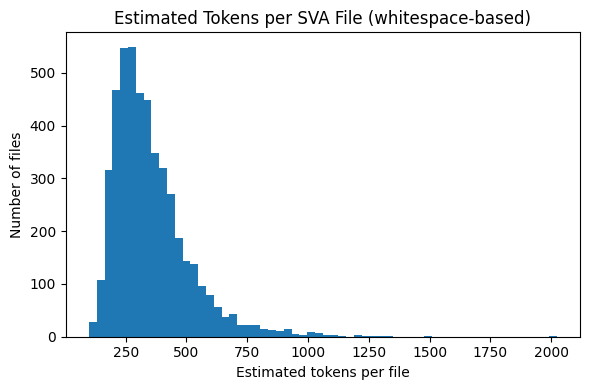

Saved Estimated Tokens per SVA File (chars/4 rule) -> ../metrex/dataset/version_1/hist_sv_est_tokens_char4.png


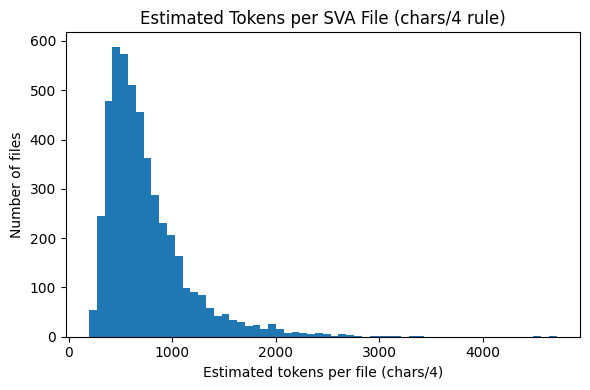

In [21]:
# Basic token stats
print("Estimated tokens (whitespace-based):")
print("  mean:", files_df["est_tokens_whitespace"].mean())
print("  median:", files_df["est_tokens_whitespace"].median())

print("\nEstimated tokens (chars/4):")
print("  mean:", files_df["est_tokens_char4"].mean())
print("  median:", files_df["est_tokens_char4"].median())

# Histogram: estimated tokens per file (whitespace)
make_histogram(
    files_df["est_tokens_whitespace"],
    title="Estimated Tokens per SVA File (whitespace-based)",
    xlabel="Estimated tokens per file",
    bins=60,
    clip_max=None,  # or set, e.g., 2000 if tails are crazy
    log_y=False,
    filename="hist_sv_est_tokens_whitespace.png",
)

# Histogram: estimated tokens per file (chars/4)
make_histogram(
    files_df["est_tokens_char4"],
    title="Estimated Tokens per SVA File (chars/4 rule)",
    xlabel="Estimated tokens per file (chars/4)",
    bins=60,
    clip_max=None,
    log_y=False,
    filename="hist_sv_est_tokens_char4.png",
)


Saved Distribution of Lines per File -> ../metrex/dataset/version_1/hist_lines_per_file.png


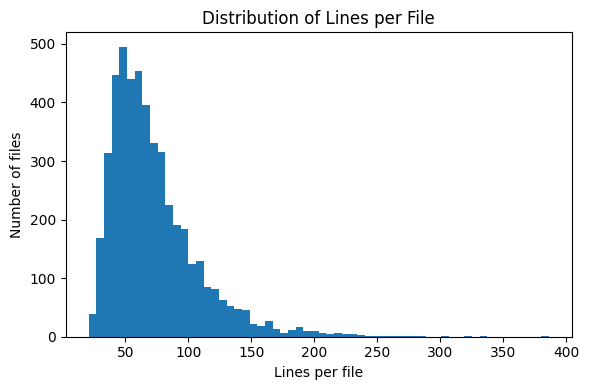

Saved Distribution of Asserts per File -> ../metrex/dataset/version_1/hist_asserts_per_file.png


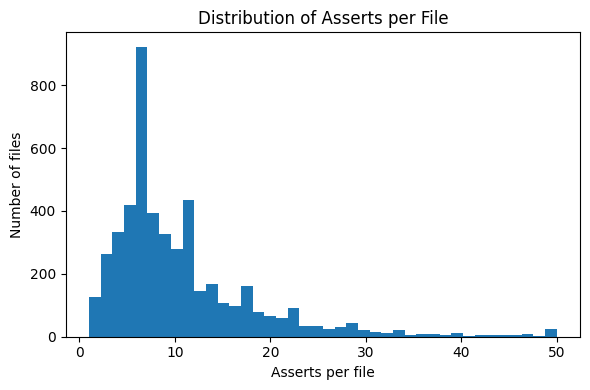

Saved Asserts per 100 LOC -> ../metrex/dataset/version_1/hist_asserts_per_100_loc.png


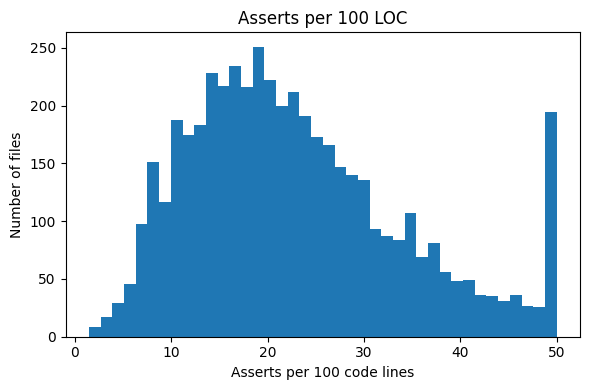

Saved Lines vs Asserts scatter -> ../metrex/dataset/version_1/scatter_lines_vs_asserts.png


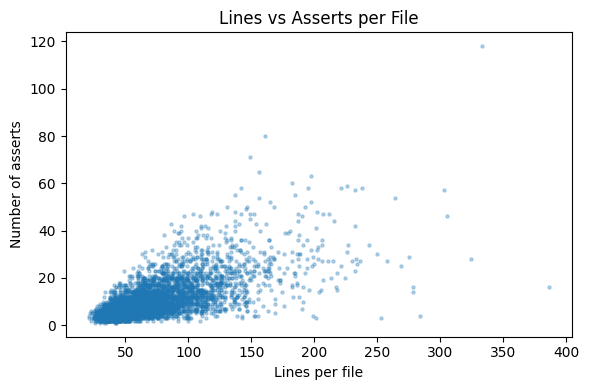

In [22]:
# Histogram: lines per file
make_histogram(
    files_df["num_lines"],
    title="Distribution of Lines per File",
    xlabel="Lines per file",
    bins=60,
    log_y=False,
    filename="hist_lines_per_file.png",
)

# Histogram: asserts per file
make_histogram(
    files_df["num_assert"],
    title="Distribution of Asserts per File",
    xlabel="Asserts per file",
    bins=40,
    clip_max=50,  # clip long tail for readability; adjust as needed
    log_y=False,
    filename="hist_asserts_per_file.png",
)

# Histogram: asserts per 100 LOC
make_histogram(
    files_df["asserts_per_100_loc"],
    title="Asserts per 100 LOC",
    xlabel="Asserts per 100 code lines",
    bins=40,
    clip_max=50,   # adjust depending on your data
    log_y=False,
    filename="hist_asserts_per_100_loc.png",
)

# Scatter: lines vs asserts
plt.figure(figsize=(6, 4))
plt.scatter(
    files_df["num_lines"],
    files_df["num_assert"],
    alpha=0.3,
    s=5,
)
plt.xlabel("Lines per file")
plt.ylabel("Number of asserts")
plt.title("Lines vs Asserts per File")
plt.tight_layout()
scatter_path = ROOT_DIR / "scatter_lines_vs_asserts.png"
plt.savefig(scatter_path, dpi=300)
print(f"Saved Lines vs Asserts scatter -> {scatter_path}")
plt.show()


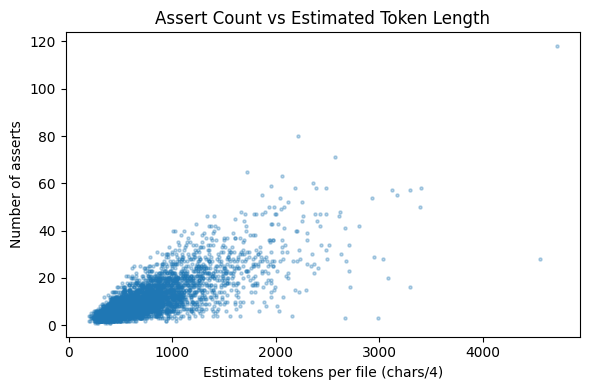

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(
    files_df["est_tokens_char4"],
    files_df["num_assert"],
    alpha=0.3,
    s=5,
)
plt.xlabel("Estimated tokens per file (chars/4)")
plt.ylabel("Number of asserts")
plt.title("Assert Count vs Estimated Token Length")
plt.tight_layout()
plt.savefig(ROOT_DIR / "scatter_tokens_vs_asserts.png", dpi=300)
plt.show()


/var/folders/k2/sk3lrt8n0p112ypy5232rv_c0000gn/T/ipykernel_83844/1509360460.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


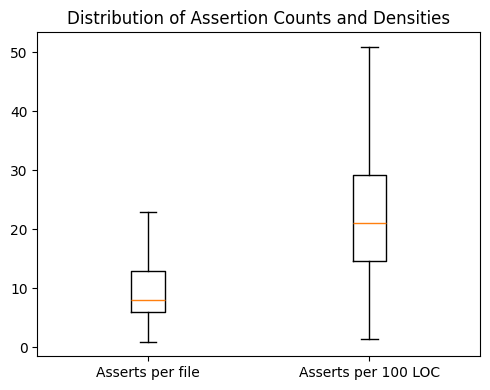

In [24]:
plt.figure(figsize=(5, 4))
plt.boxplot(
    [
        files_df["num_assert"],
        files_df["asserts_per_100_loc"],
    ],
    labels=["Asserts per file", "Asserts per 100 LOC"],
    showfliers=False,  # hide crazy outliers for cleaner box
)
plt.title("Distribution of Assertion Counts and Densities")
plt.tight_layout()
plt.savefig(ROOT_DIR / "boxplot_asserts_and_density.png", dpi=300)
plt.show()


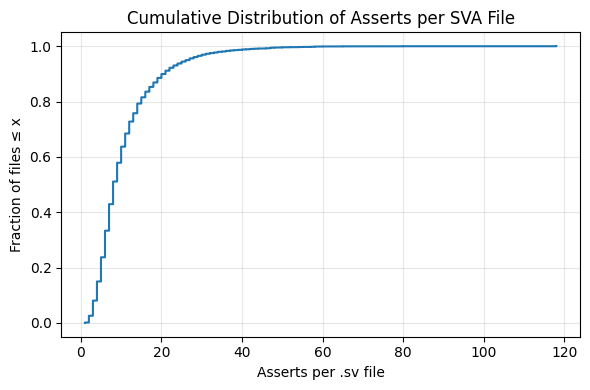

In [25]:
import numpy as np

values = np.sort(files_df["num_assert"].values)
n = len(values)
y = np.arange(1, n + 1) / n

plt.figure(figsize=(6, 4))
plt.step(values, y, where="post")
plt.xlabel("Asserts per .sv file")
plt.ylabel("Fraction of files ≤ x")
plt.title("Cumulative Distribution of Asserts per SVA File")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT_DIR / "cdf_asserts_per_file.png", dpi=300)
plt.show()


Saved: ../metrex/dataset/version_1/hist_lines_per_file_hd.png


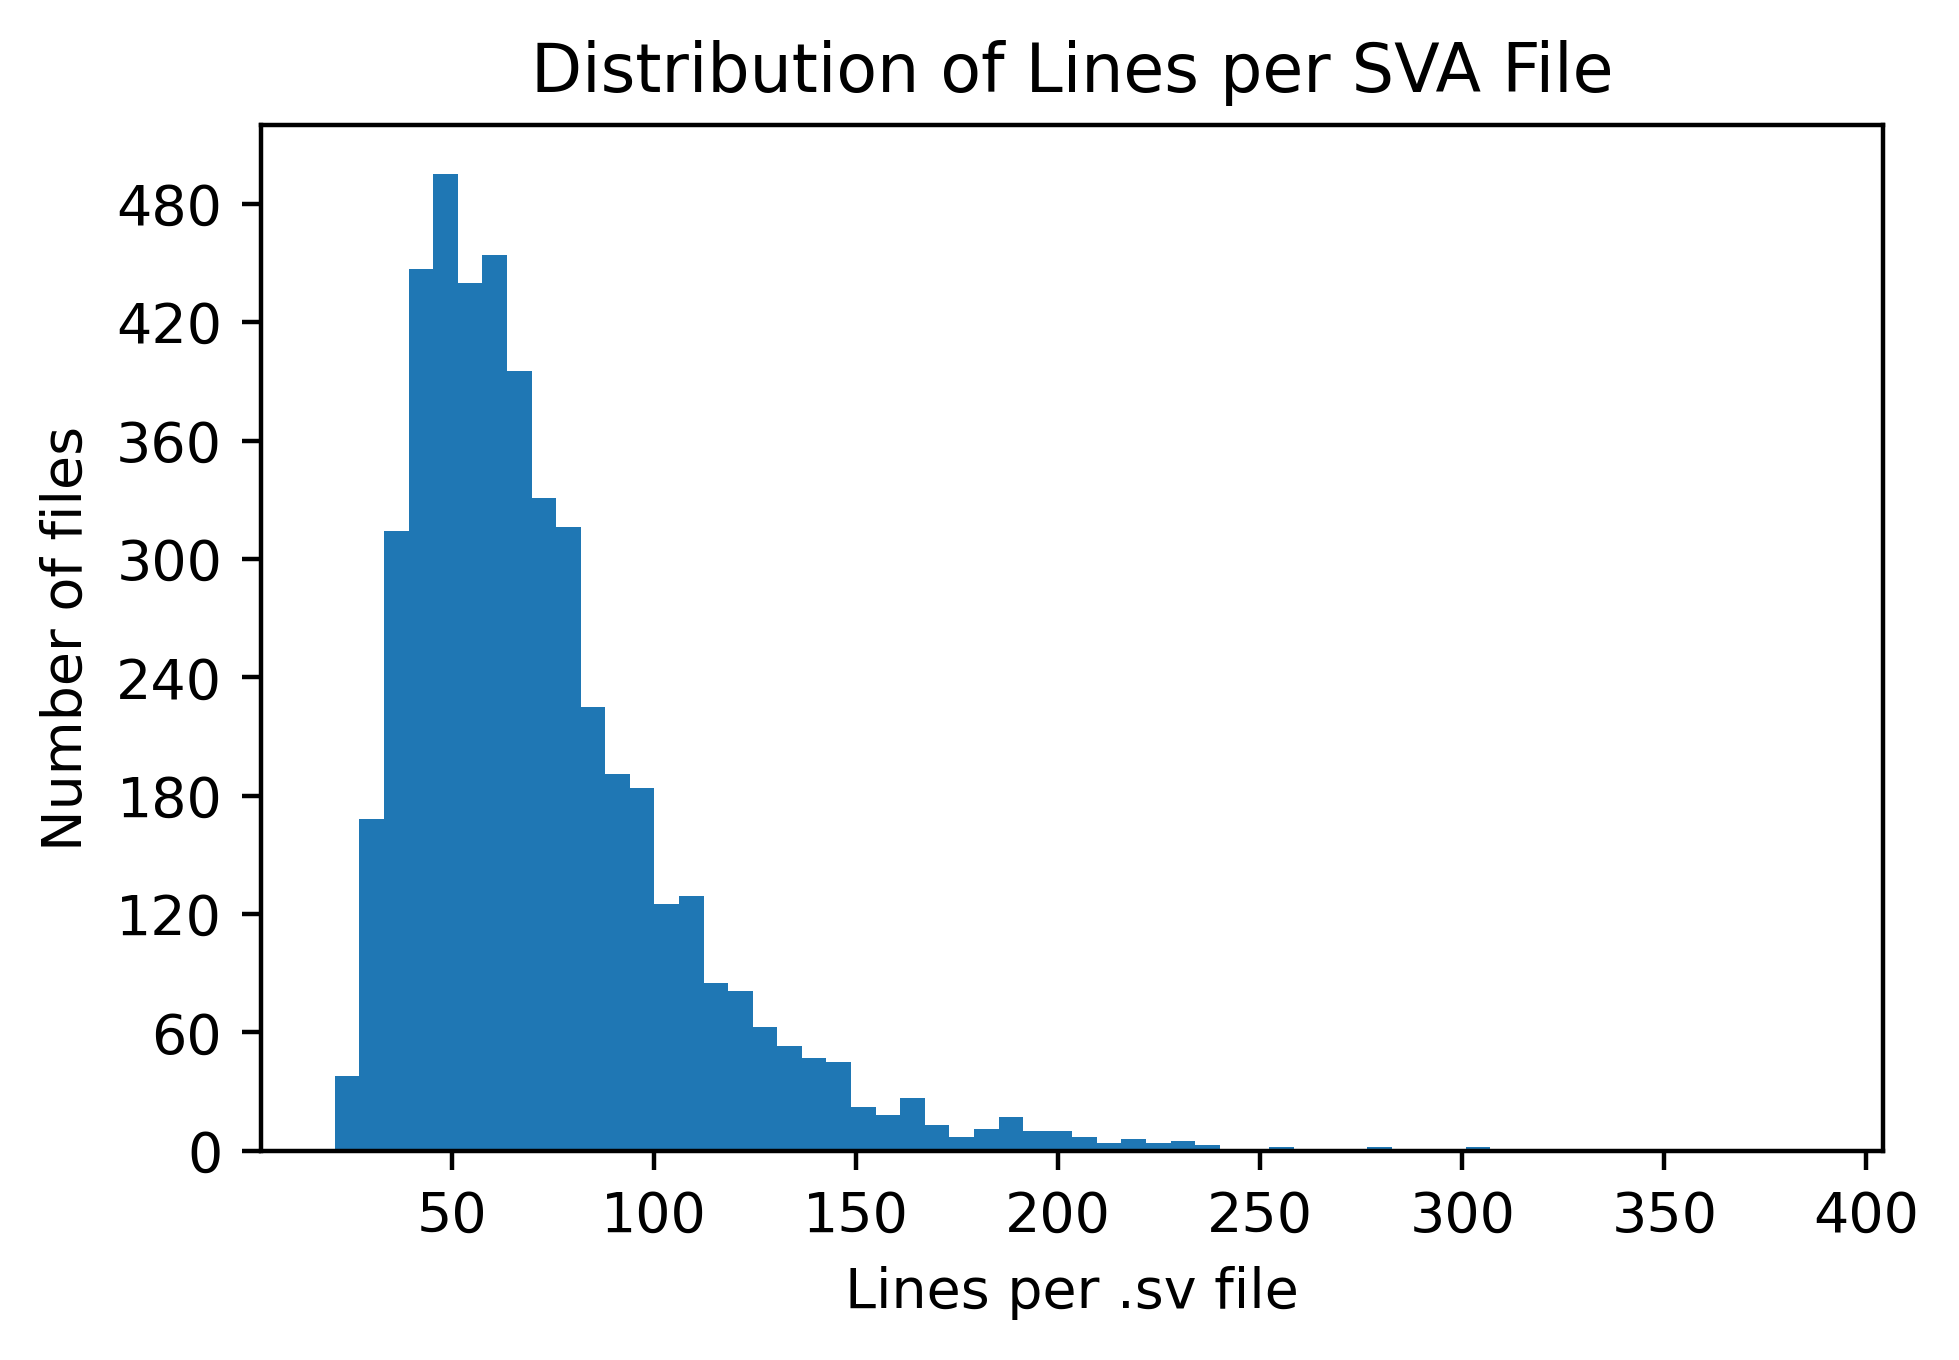

Saved: ../metrex/dataset/version_1/hist_asserts_per_file_hd.png


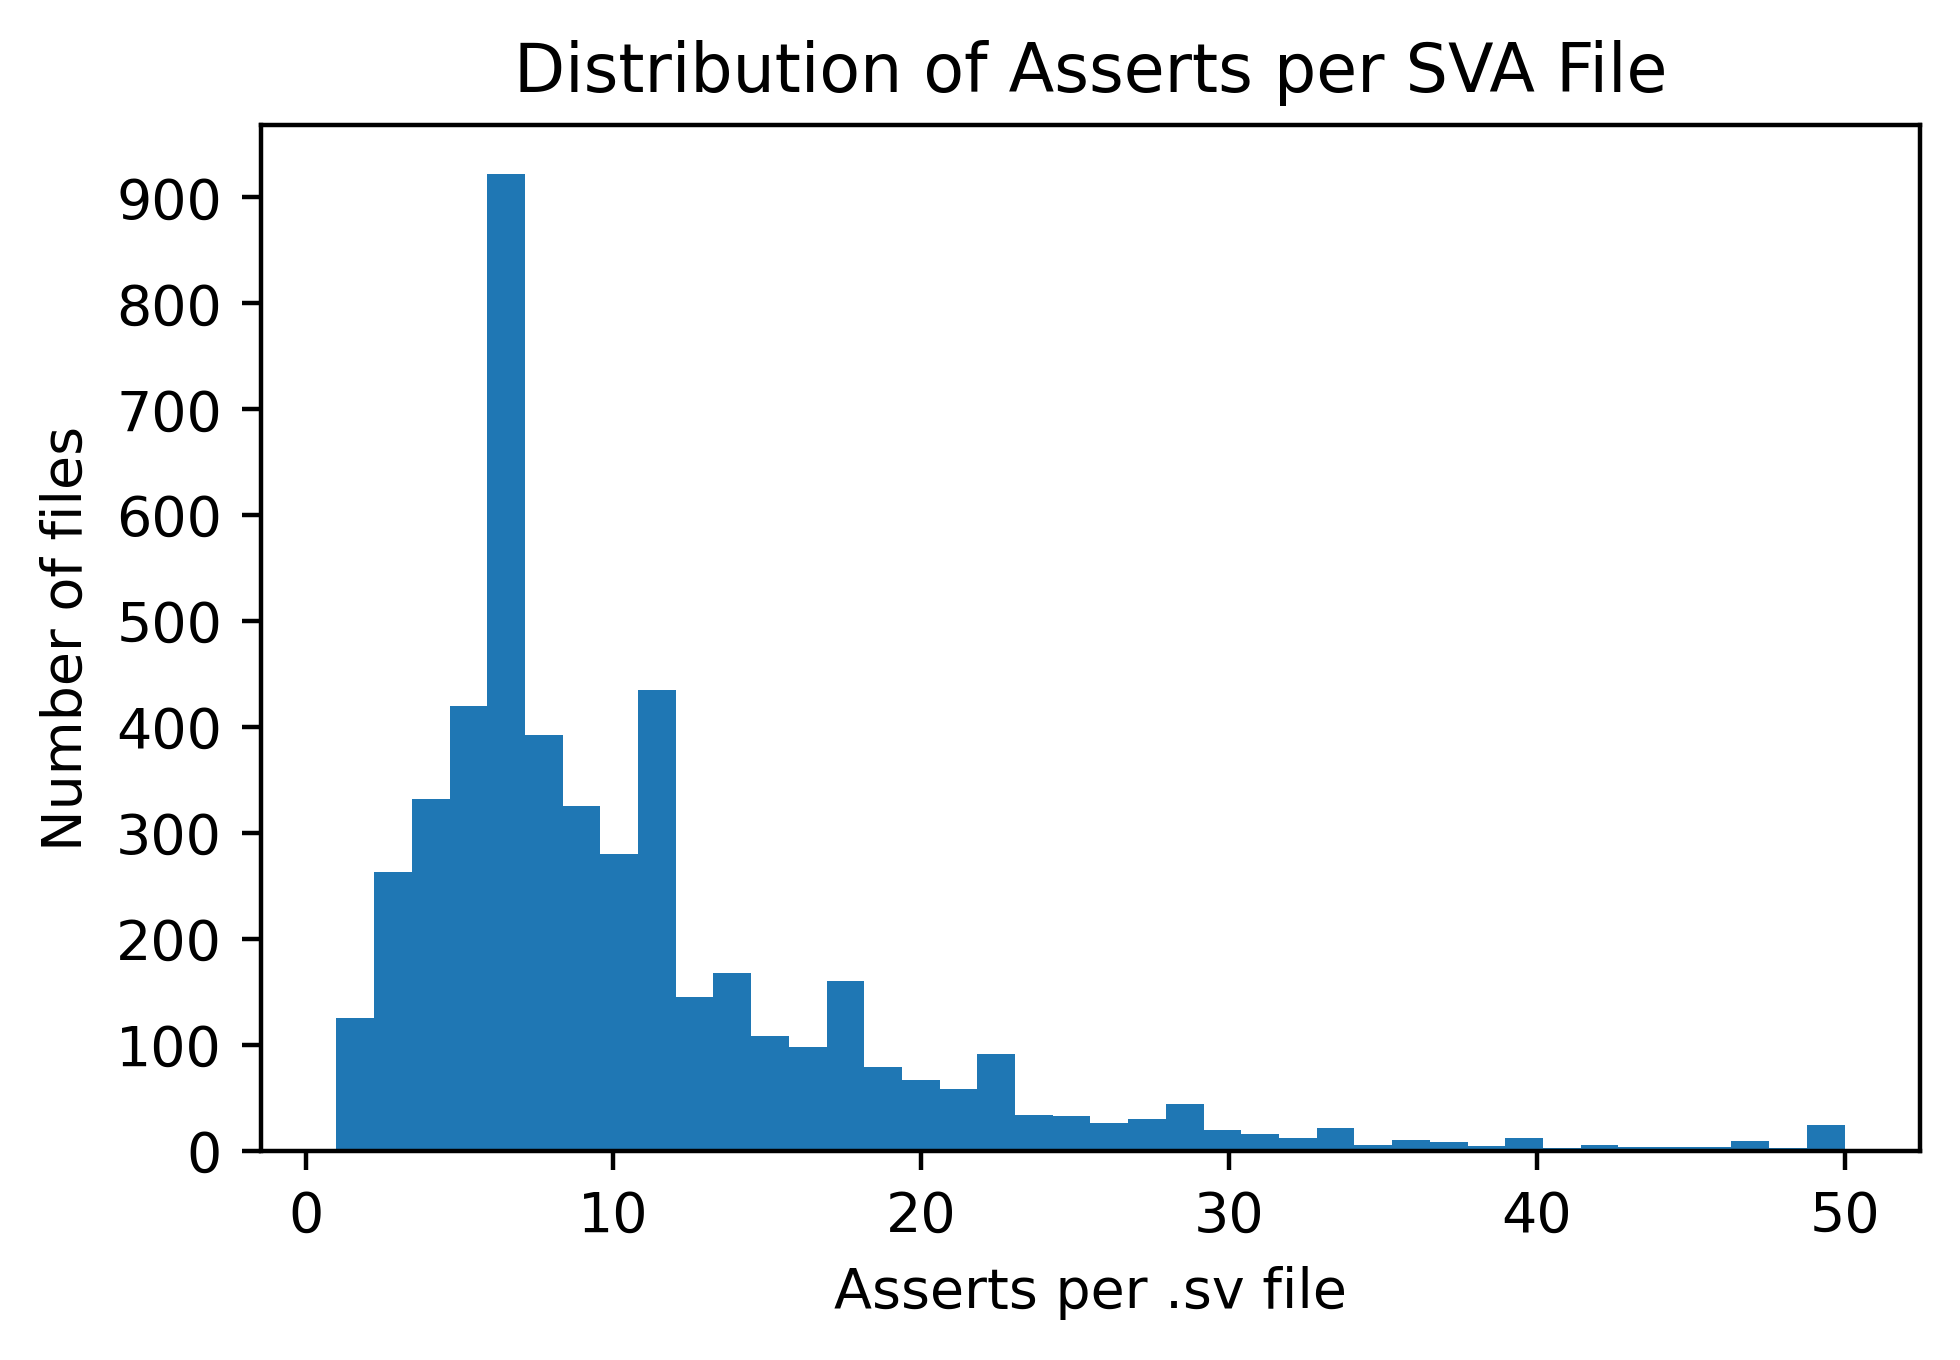

Saved: ../metrex/dataset/version_1/hist_asserts_per_100_loc_hd.png


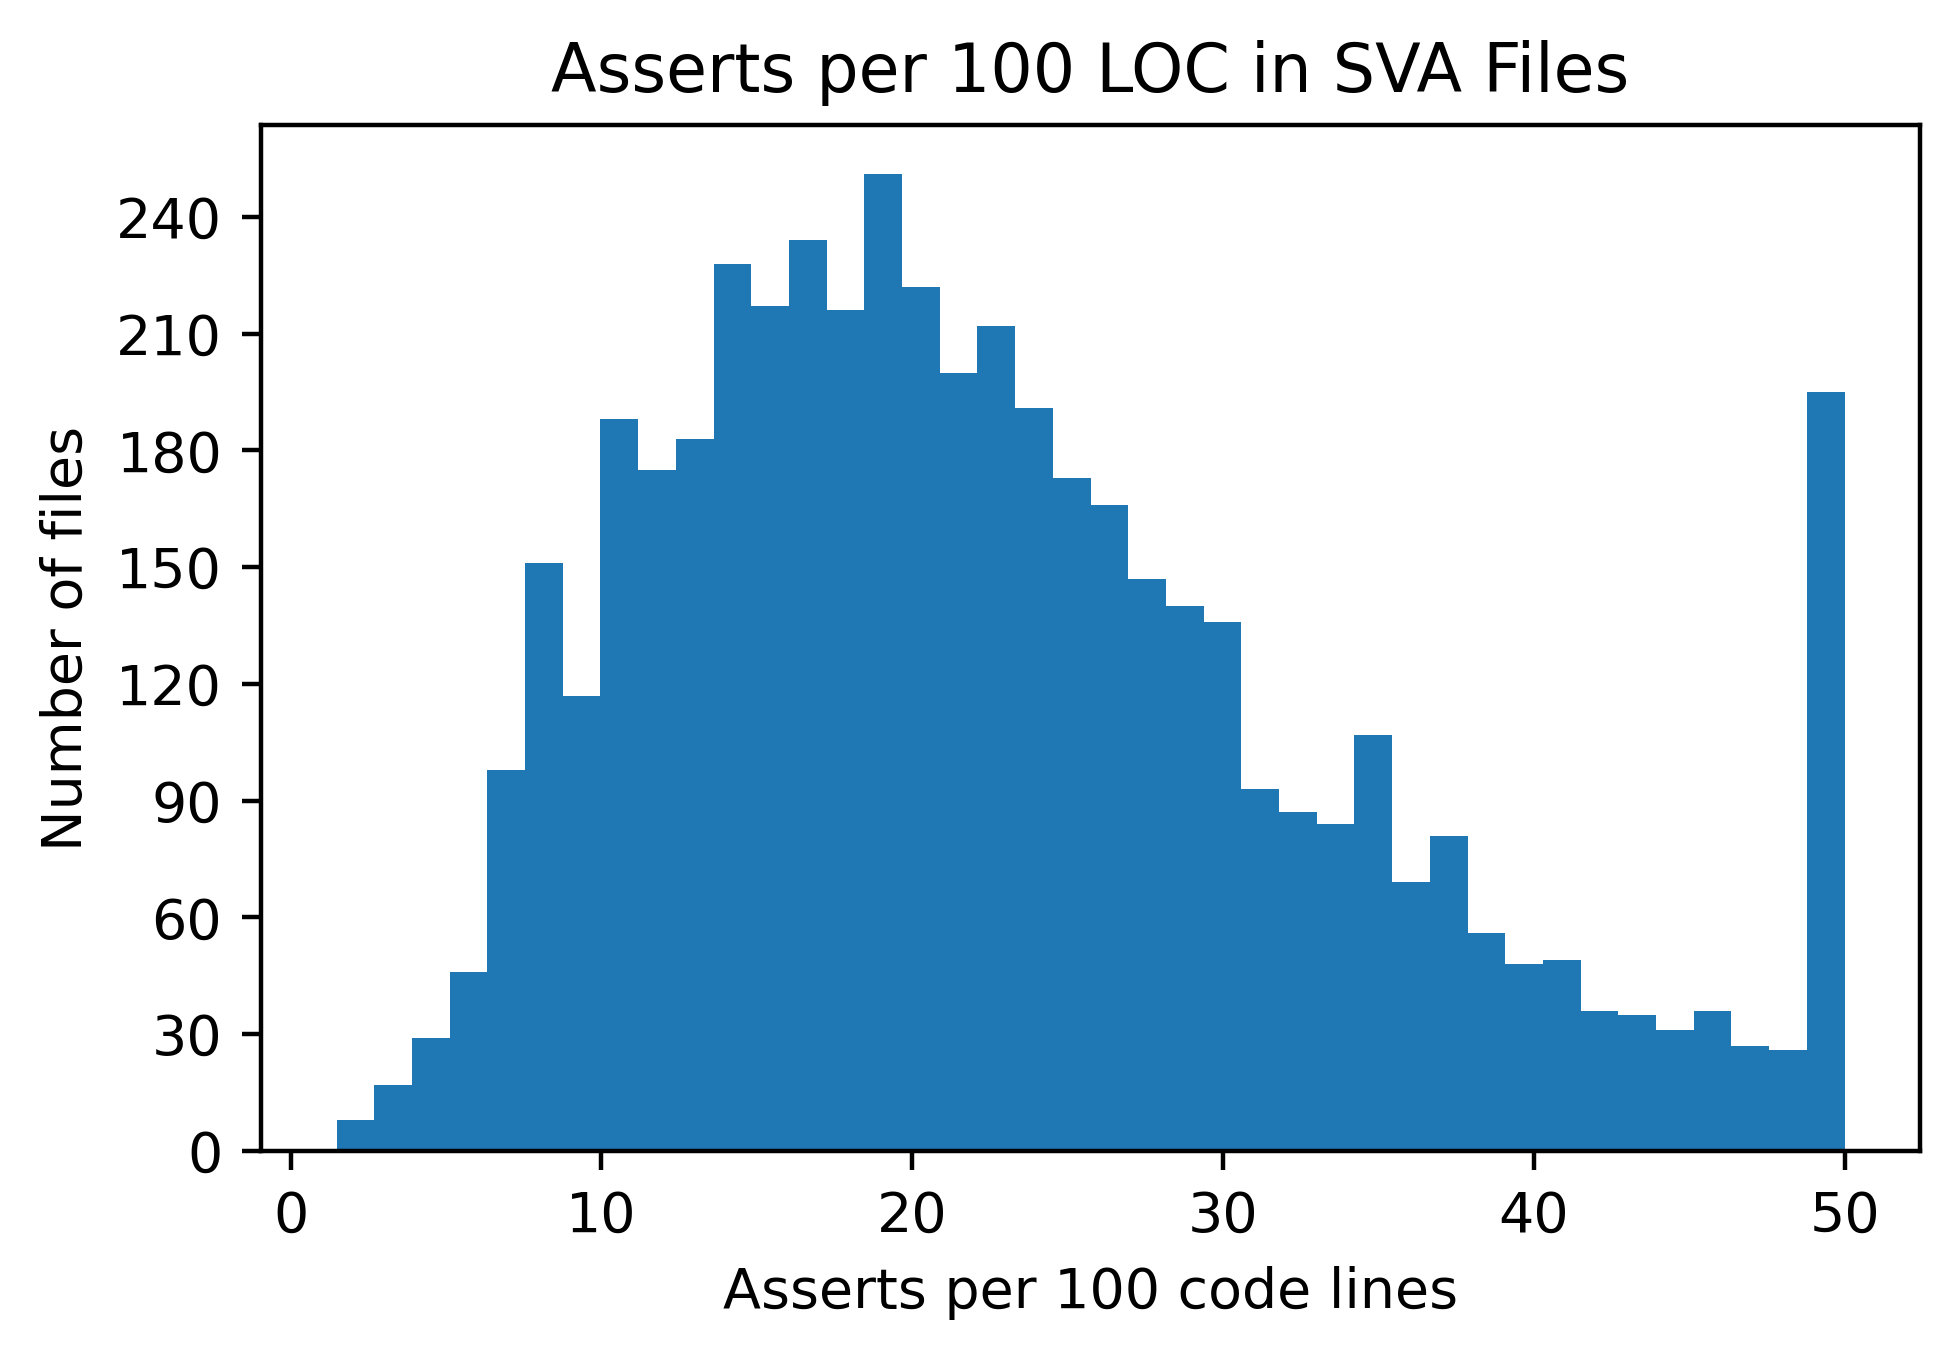

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator

# --------------------------------------------------
# Common plot settings so all figures look identical
# --------------------------------------------------
FIGSIZE = (5, 3.5)   # width, height in inches (tweak if you want)
DPI     = 400        # high resolution for printing/posters

OUT_DIR = ROOT_DIR   # or Path("../figures") if you want a separate folder

def save_histogram(
    data,
    title,
    xlabel,
    filename,
    bins=40,
    clip_max=None,
):
    """Make a histogram with consistent styling and save it."""
    series = data.dropna()
    if clip_max is not None:
        series = series.clip(upper=clip_max)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    ax.hist(series, bins=bins)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of files")

    # y-axis: normal integers, no scientific notation
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    fig.tight_layout()
    out_path = OUT_DIR / filename
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {out_path}")

    plt.show()


# 1) Lines per file
save_histogram(
    files_df["num_lines"],
    title="Distribution of Lines per SVA File",
    xlabel="Lines per .sv file",
    filename="hist_lines_per_file_hd.png",
    bins=60,
    clip_max=None,   # or something like 500 if you want to squash outliers
)

# 2) Asserts per file
save_histogram(
    files_df["num_assert"],
    title="Distribution of Asserts per SVA File",
    xlabel="Asserts per .sv file",
    filename="hist_asserts_per_file_hd.png",
    bins=40,
    clip_max=50,     # clip long tail for a cleaner poster figure; adjust as needed
)

# 3) Asserts per 100 LOC
save_histogram(
    files_df["asserts_per_100_loc"],
    title="Asserts per 100 LOC in SVA Files",
    xlabel="Asserts per 100 code lines",
    filename="hist_asserts_per_100_loc_hd.png",
    bins=40,
    clip_max=50,     # adjust depending on how spiky your distribution is
)


Saved: ../metrex/dataset/version_1/jasper_syntax_check_bar_hd.png


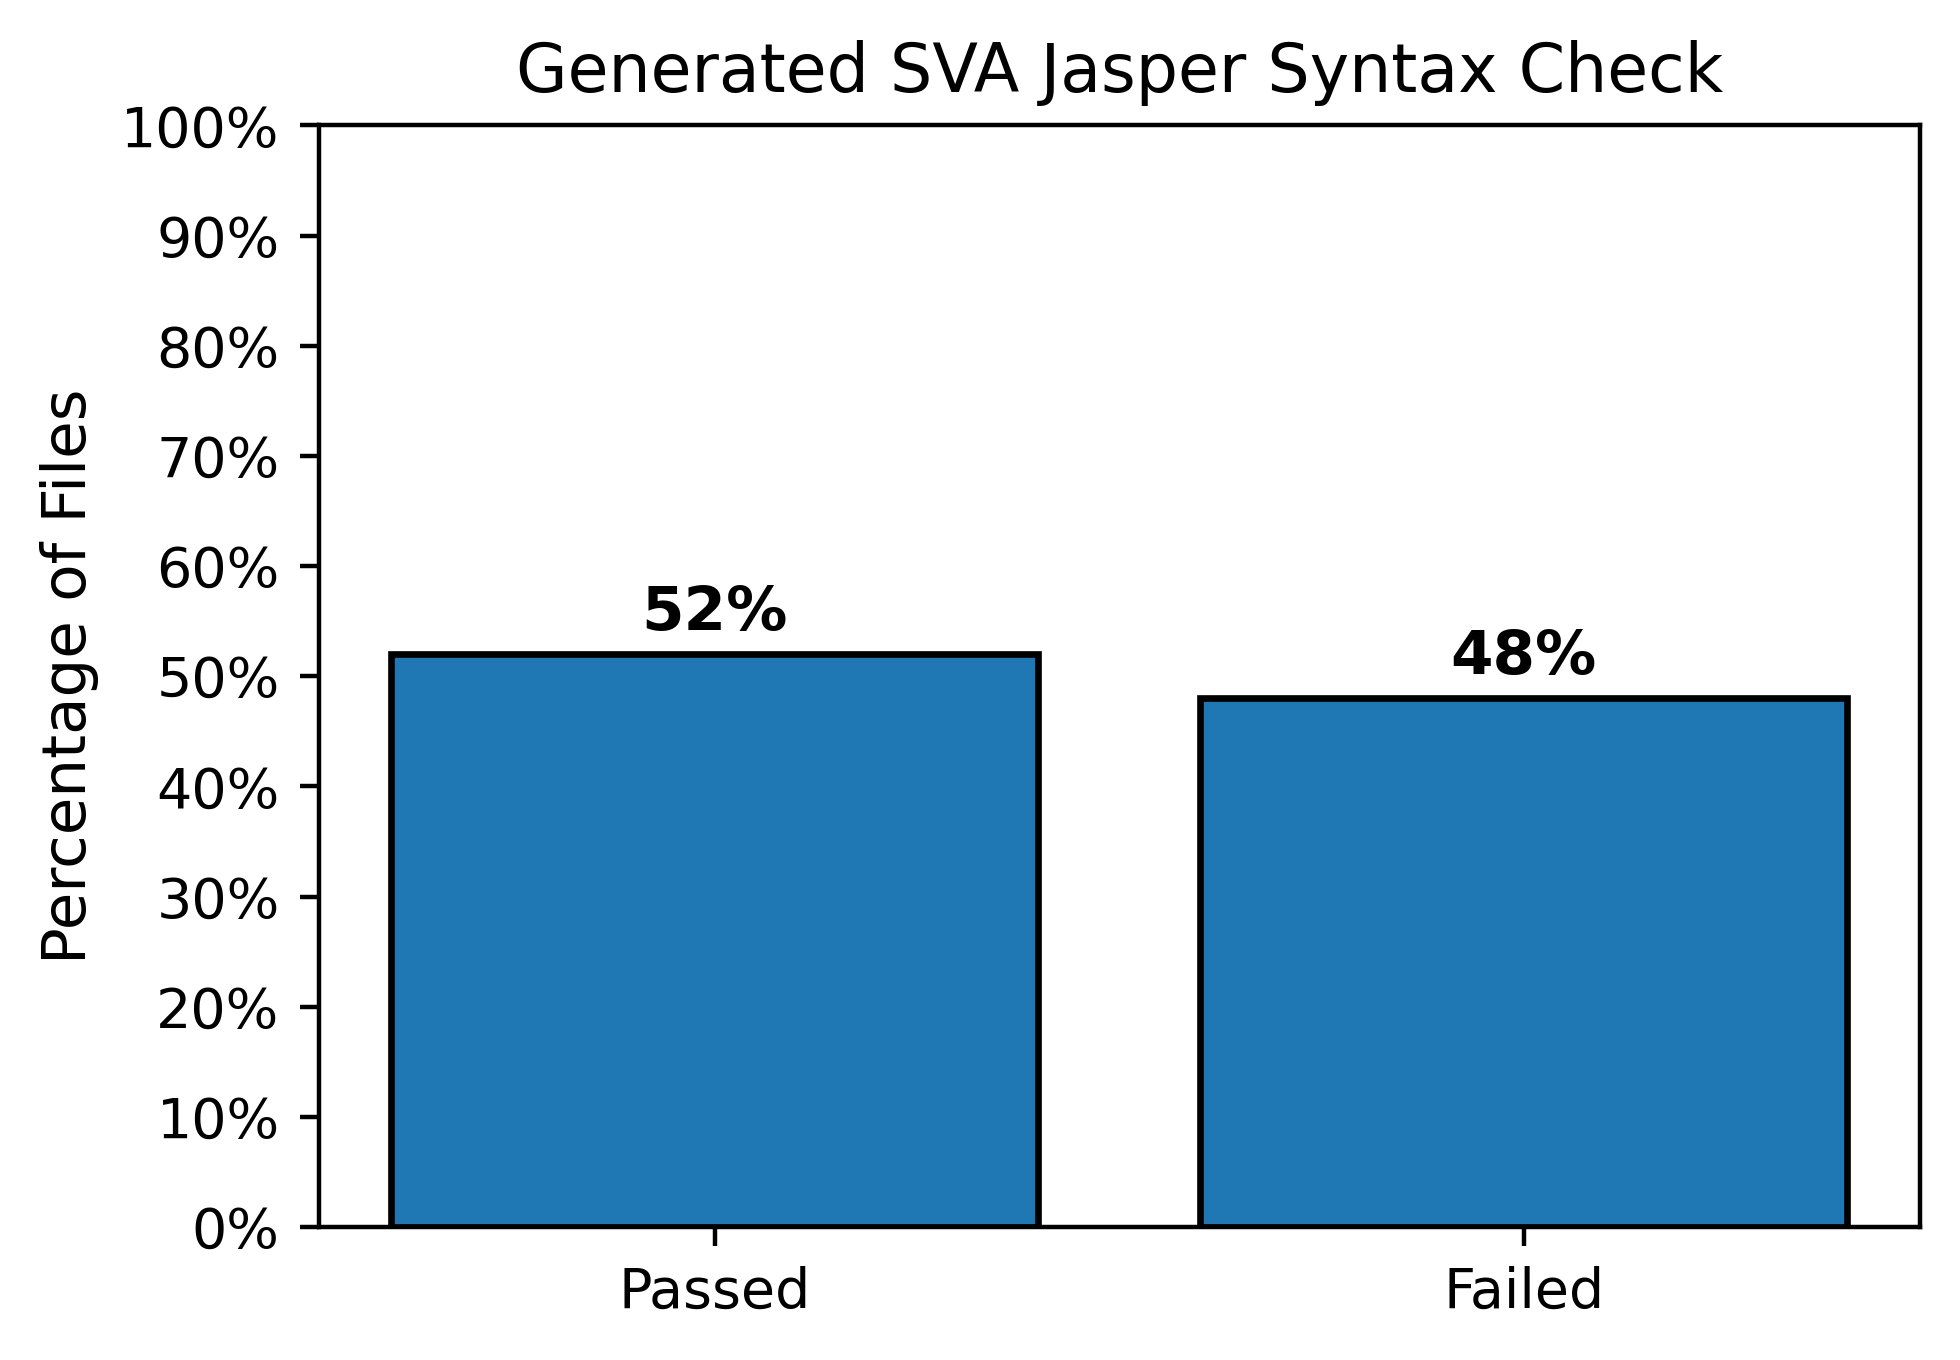

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# ---------------------------------------------
# Uses same FIGSIZE / DPI / OUT_DIR as earlier
# ---------------------------------------------
# If you already defined FIGSIZE, DPI, OUT_DIR earlier, remove this block:
FIGSIZE = (5, 3.5)
DPI = 400
OUT_DIR = ROOT_DIR

# Data
labels = ["Passed", "Failed"]
values = [52, 48]  # percentages

# Colors
colors = ["#ff8f00", "#000000"]  # orange, black

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

bars = ax.bar(labels, values, edgecolor="black", linewidth=1.2)

# Title + axis labels
ax.set_title("Generated SVA Jasper Syntax Check", fontsize=12)
ax.set_ylabel("Percentage of Files", fontsize=11)

# Y-axis formatting: 0% to 100%, ticks every 10%
ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(PercentFormatter())

# Add exact % above each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1,   # slightly above bar
        f"{val}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

fig.tight_layout()

# Save HD image
out_path = OUT_DIR / "jasper_syntax_check_bar_hd.png"
fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()
